In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Import instacart.csv/parquet

df = pd.read_parquet('../data/processed/instacart.parquet')
df.head()

,Unnamed: 0,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,prices,...,Surnam,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division
0,0,1187899,11,4,8,14.0,1,1,Soda,9.0,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
1,1,1187899,11,4,8,14.0,2,1,Organic String Cheese,8.6,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
2,2,1187899,11,4,8,14.0,3,1,0% Greek Strained Yogurt,12.6,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
3,3,1187899,11,4,8,14.0,4,1,XL Pick-A-Size Paper Towel Rolls,1.0,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
4,4,1187899,11,4,8,14.0,5,1,Milk Chocolate Almonds,6.8,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central


In [3]:
df.shape

(1384706, 23)

In [4]:
df.describe()

,Unnamed: 0,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,prices,Age,n_dependants,income
count,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384618e+06,1.384706e+06,1.384706e+06,1.384706e+06
mean,6.923525e+05,1.706298e+06,1.709135e+01,2.701394e+00,1.357761e+01,1.706626e+01,8.758180e+00,5.985964e-01,1.411711e+01,4.938182e+01,1.498778e+00,9.766228e+04
std,3.997303e+05,9.897342e+05,1.661400e+01,2.167637e+00,4.238461e+00,1.042639e+01,7.423973e+00,4.901825e-01,6.802253e+02,1.843685e+01,1.117567e+00,4.199139e+04
min,0.000000e+00,1.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.800000e+01,0.000000e+00,2.591100e+04
25%,3.461762e+05,8.433700e+05,6.000000e+00,1.000000e+00,1.000000e+01,7.000000e+00,3.000000e+00,0.000000e+00,4.300000e+00,3.300000e+01,0.000000e+00,6.485900e+04
50%,6.923525e+05,1.701880e+06,1.100000e+01,3.000000e+00,1.400000e+01,1.500000e+01,7.000000e+00,1.000000e+00,7.400000e+00,4.900000e+01,1.000000e+00,9.576500e+04
75%,1.038529e+06,2.568023e+06,2.100000e+01,5.000000e+00,1.700000e+01,3.000000e+01,1.200000e+01,1.000000e+00,1.130000e+01,6.500000e+01,2.000000e+00,1.268178e+05
max,1.384705e+06,3.421070e+06,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01,8.000000e+01,1.000000e+00,9.999900e+04,8.100000e+01,3.000000e+00,5.910890e+05


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1384706 entries, 0 to 1384705
Data columns (total 23 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Unnamed: 0              1384706 non-null  int64  
 1   order_id                1384706 non-null  int64  
 2   order_number            1384706 non-null  int64  
 3   order_dow               1384706 non-null  int64  
 4   order_hour_of_day       1384706 non-null  int64  
 5   days_since_prior_order  1384706 non-null  float64
 6   add_to_cart_order       1384706 non-null  int64  
 7   reordered               1384706 non-null  int64  
 8   product_name            1383473 non-null  str    
 9   prices                  1384618 non-null  float64
 10  department              1384618 non-null  str    
 11  aisle                   1384618 non-null  str    
 12  First Name              1309274 non-null  str    
 13  Surnam                  1384706 non-null  str    
 14  Gender       

In [6]:
## Data Prep
orders_by_dow = (df[['order_id','order_dow']]
                 .drop_duplicates()
                 .groupby('order_dow')
                 .size())

type(orders_by_dow)


pandas.Series

In [7]:
orders_by_dow

order_dow
0    27465
1    19672
2    16119
3    15687
4    15959
5    17406
6    18901
dtype: int64

In [8]:
d = pd.DataFrame(orders_by_dow).reset_index()
d

,order_dow,0
0,0,27465
1,1,19672
2,2,16119
3,3,15687
4,4,15959
5,5,17406
6,6,18901


In [9]:
d.columns

Index(['order_dow', 0], dtype='object')

In [10]:
d.rename(columns={0:'number_of_orders'},inplace=True)
d

,order_dow,number_of_orders
0,0,27465
1,1,19672
2,2,16119
3,3,15687
4,4,15959
5,5,17406
6,6,18901


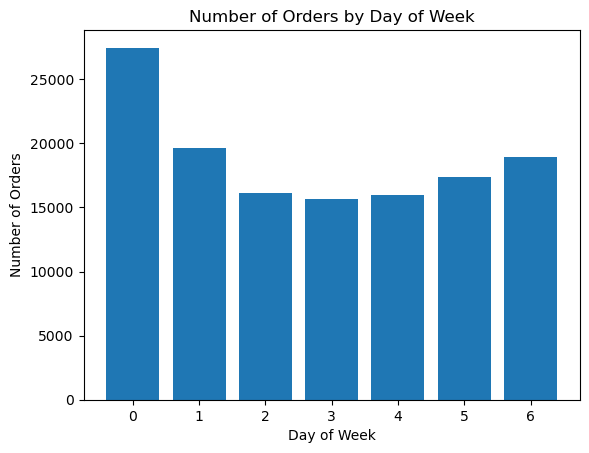

In [11]:
plt.figure()
plt.bar(orders_by_dow.index,orders_by_dow.values)
plt.title('Number of Orders by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.show()

In [13]:
orders_by_hour = (
    df[["order_id", "order_hour_of_day"]]
    .drop_duplicates()
    .groupby("order_hour_of_day")
    .size()
)

orders_by_hour.head()

order_hour_of_day
0    852
1    507
2    305
3    223
4    218
dtype: int64

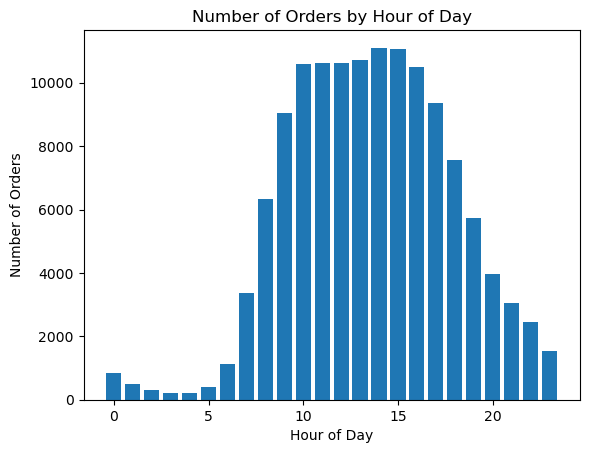

In [15]:
orders_by_hour = (
    df[["order_id", "order_hour_of_day"]]
    .drop_duplicates()
    .groupby("order_hour_of_day")
    .size()
)

plt.figure()
plt.bar(orders_by_hour.index, orders_by_hour.values)
plt.title("Number of Orders by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.show()